In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [3]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### Simple model on miRNA alignments:

In [7]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [8]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [9]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

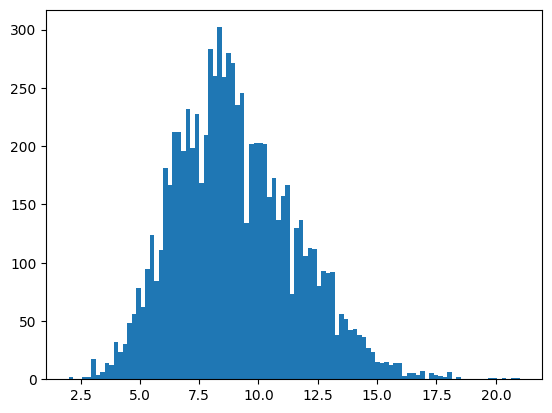

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [11]:
true_alpha = -9
## true_alpha = -np.median(scores)

In [12]:
logit_scores = logit_partial_scores(scores, true_alpha)

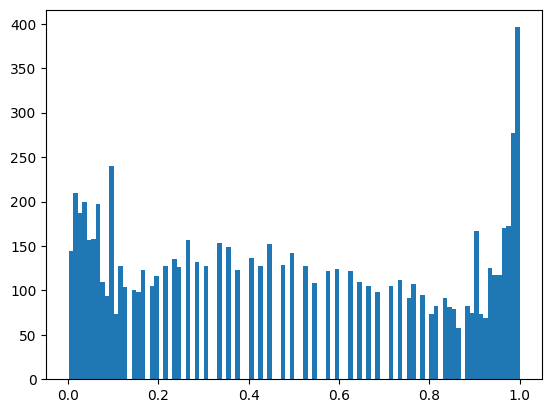

In [13]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

### Test Run

In [14]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False, False,  True], shape=(8193,))

In [15]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL) ## This is different 

Sum of log-logit scores: -10002.78024009512
True LogL: -3307.380240095122


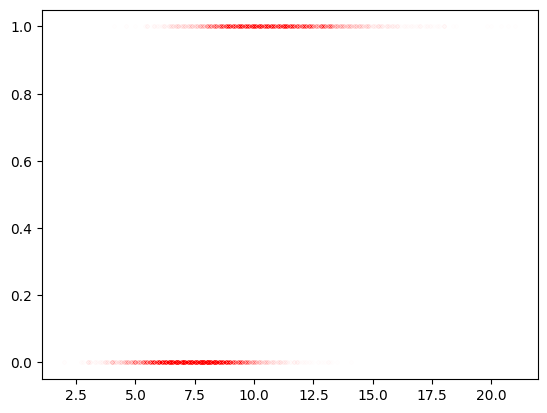

In [16]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

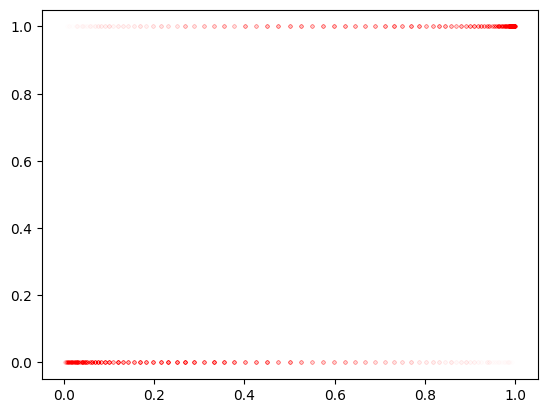

In [17]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [18]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [ ]:
NITER = 50# original 50

In [20]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

Alphabet:
TAGC


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Initial parameters:
{'alpha': np.float64(-8.16937626320343), 'match_score': np.float64(0.929173438656762), 'mismatch_score': np.float64(-0.8262869352464813), 'open_gap_score': np.float64(-1.1662165723511335), 'extend_gap_score': np.float64(-0.10425061003399534)}
Start of iteration 0
Current alpha: -8.16937626320343
Current logL: -3335.869901629582
Updated alpha: -8.334657787503849
Updated logL: -3320.6952275174426
New subgradient:
{'Substitutions': Array([[-21.70666818, -19.10149957, -16.340272  , -14.31025778],
       [ -0.72083332,  39.19881473,   0.11862342,   4.19697541],
       [-39.0063212 , -23.6260578 , 100.53350185, -20.69649542],
       [-29.06113623, -33.03428596, -10.44829549,   8.4426905 ]],
         alphabet='TAGC'), 'Gap opens': np.float64(137.60536894971798), 'Gap extends': np.float64(158.03926528473733)}
Stepsize: 1e-05
Gap open step: 0.00137605368949718
Gap extend step: 0.0015803926528473733
Match step: 0.0012646833889689655
Mismatch step: -0.0020202985594877467
New p

In [21]:
print(params['final_loglik'])

-3320.306470292294


In [22]:
print(params['final_loglik'])

-3320.306470292294


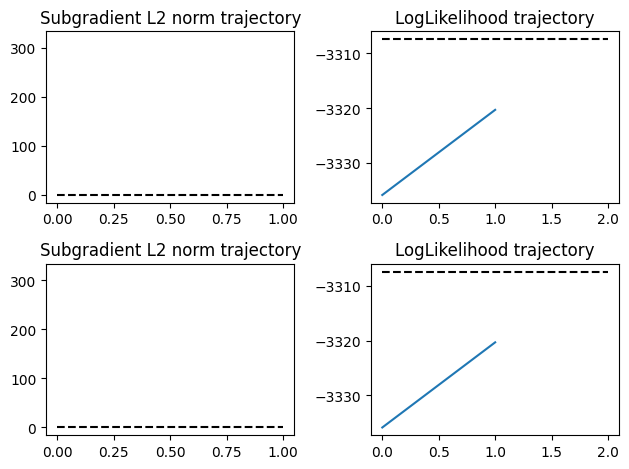

In [23]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

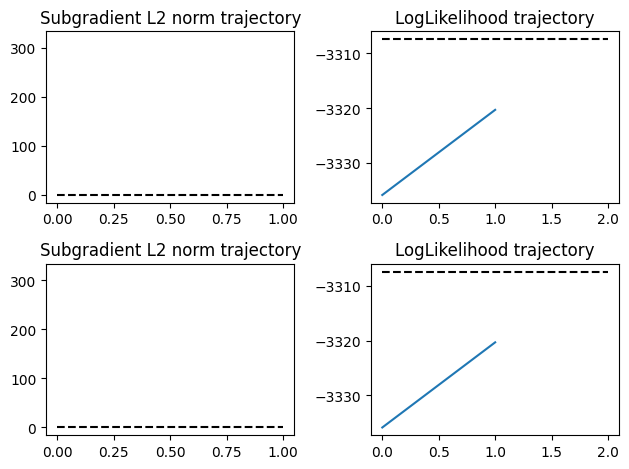

In [24]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [25]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 0.9304381220457311
-1 -0.828307233805969
-1.2 -1.1648405186616364
-0.1 -0.10267021738114797
-9 -8.334657787503849


### Step function parameters experiment

In [26]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [27]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [28]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [ ]:
NITER = 200

In [ ]:
# Get the iteration at which logL is hit (speed)
def get_logL__reached_iter(params, true_logL):
    for i, logL in enumerate(params['loglik_trajectory']):
        if logL >= true_logL:
            return i
    return None

In [31]:
# Get the value at the last iteration of the simulation
def get_final_val(params):
    return params['loglik_trajectory'][-1]

In [32]:
estimalign_results_step = []

logL_reached_iters = []
final_vals = []

for stepl in steplengths:
    const_step = create_constant_step(stepl)
    
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results_step.append(params)

    logL_reached_iter = get_logL__reached_iter(params, true_logL)
    logL_reached_iters.append(logL_reached_iter if logL_reached_iter is not None else np.inf) # infinity so that they dont show on the scatter plot 

    final_val = get_final_val(params)
    final_vals.append(final_val)

    if logL_reached_iter is not None:
        print(f"step {stepl:.2e}, surpassed logL at {logL_reached_iter} and reached a maximum value of {final_val}")
    else:
        print(f"step {stepl:.2e} did NOT hit logL")

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood
step=5.00e-06, did NOT hit logL


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood
step=1.00e-05, did NOT hit logL


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

Did not rach LogLikelihood
step=4.00e-05, did NOT hit logL


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood
step=4.50e-05, did NOT hit logL


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood
step=5.00e-05, did NOT hit logL


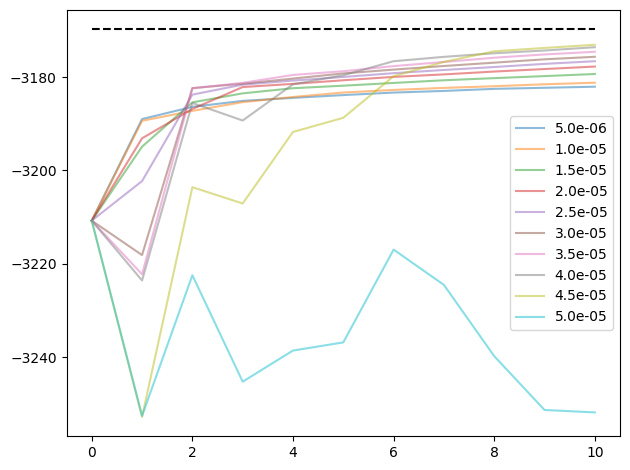

In [33]:
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.tight_layout()
plt.savefig("results/simple/step_experiment_full_trajectories.png", dpi=160)

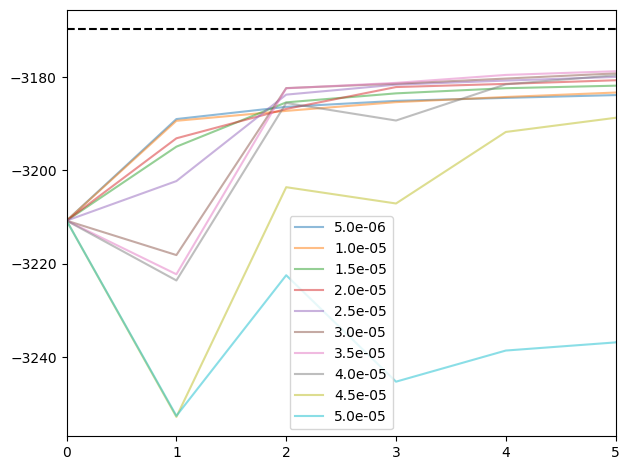

In [34]:
# zoom on start
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig("results/simple/step_experiment_zoom_start.png", dpi=160)

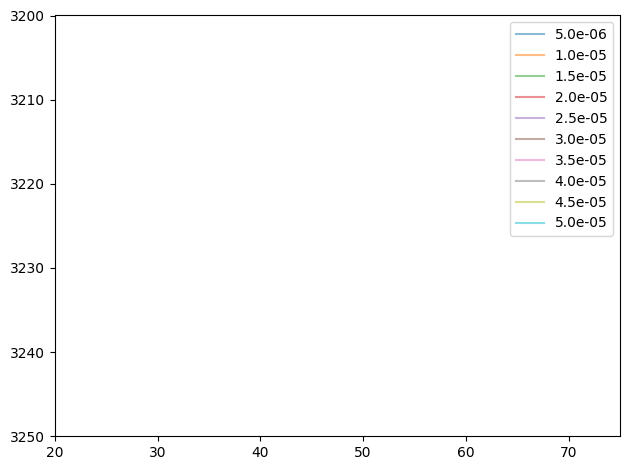

In [35]:
# zoom where most trajectories hit logL
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(20, 75) 
plt.ylim(3250, 3200)
plt.tight_layout()
plt.savefig("results/simple/step_experiment_zoom_mid.png", dpi=160)

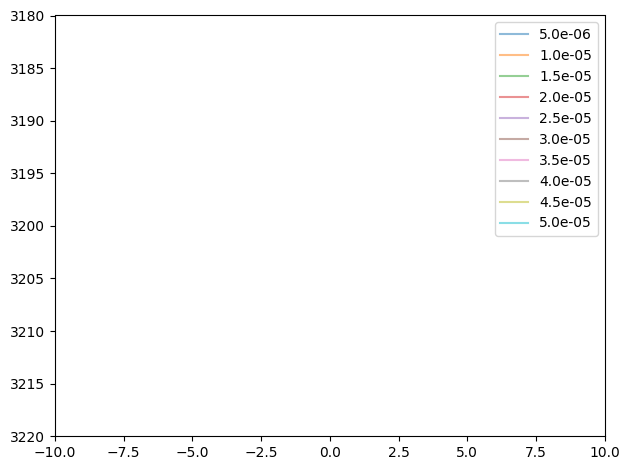

In [36]:
# zoom on the end of the iterations
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(NITER-20, NITER) 
plt.ylim(3220, 3180)
plt.tight_layout()
plt.savefig("results/simple/step_experiment_zoom_end.png", dpi=160)

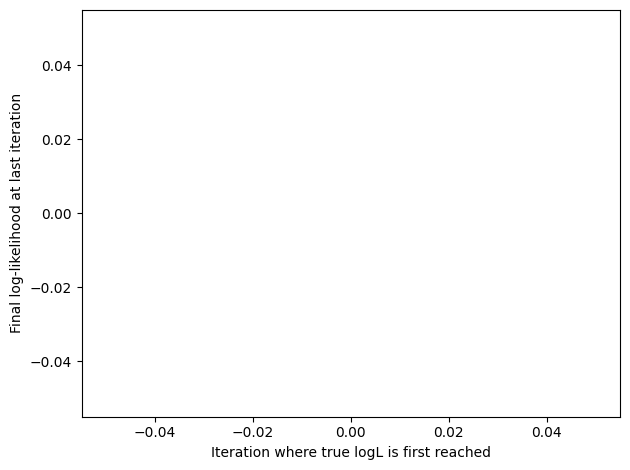

In [37]:
plt.figure()

logL_reached_iters_arr = np.array(logL_reached_iters)
final_vals_arr = np.array(final_vals)

plt.scatter(logL_reached_iters_arr, final_vals_arr)

for i, steplength in enumerate(steplengths):
    if np.isfinite(logL_reached_iters_arr[i]):
        plt.annotate(
            f"{steplength:.2e}",
            (logL_reached_iters_arr[i], final_vals_arr[i])
        )

plt.xlabel("Iteration where true logL is first reached")
plt.ylabel("Final log-likelihood at last iteration")
plt.tight_layout()
plt.savefig("results/simple/step_experiment_scatter_hit_vs_final.png", dpi=160)

### Replicates

In [ ]:
REPS = 20 #20
NITER = 200

In [ ]:
const_step = create_constant_step(3.0e-05) # choose best step from prev exp 
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [40]:
# Checks if the chosen step size is stable in convergence across different datasets
estimalign_results_rep = []
true_logLs = []

logL_reached_iters_rep = []
final_vals_rep = []

for _ in range(REPS):
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    true_logLs.append(true_logL)
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results_rep.append(params)

    logL_reached_iter = get_logL__reached_iter(params, true_logL)
    
    logL_reached_iters_rep.append(
        logL_reached_iter if logL_reached_iter is not None else np.inf
    )

    final_vals_rep.append(get_final_val(params))

for i, it in enumerate(logL_reached_iters_rep):
    if np.isfinite(it):
        print(f"rep {i} hit logL at iteration {it}, final={final_vals_rep[i]:.2f}")
    else:
        print(f"rep {i} did NOT hit logL, final={final_vals_rep[i]:.2f}")

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

Did not rach LogLikelihood


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Did not rach LogLikelihood
rep 0 did NOT hit logL, final=-3276.34
rep 1 did NOT hit logL, final=-3282.69
rep 2 did NOT hit logL, final=-3294.98
rep 3 did NOT hit logL, final=-3264.10
rep 4 did NOT hit logL, final=-3301.20
rep 5 did NOT hit logL, final=-3326.56
rep 6 did NOT hit logL, final=-3324.76
rep 7 did NOT hit logL, final=-3342.13
rep 8 did NOT hit logL, final=-3367.22
rep 9 did NOT hit logL, final=-3312.17


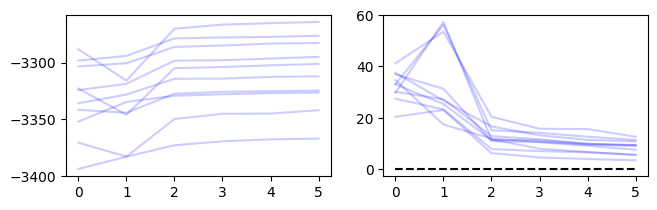

In [41]:
plt.figure(figsize=(7.5, 2.1))
plt.subplot(121)
for params in estimalign_results_rep:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.2, color='b')
plt.subplot(122)
plt.plot([0, NITER], [0, 0], 'k--')
for params, tlL in zip(estimalign_results_rep, true_logLs):
    plt.plot(np.arange(NITER+1), tlL - params['loglik_trajectory'], alpha=0.2, color='b')

plt.savefig("results/simple/replicates_trajectories.png", dpi=160)